#### Imports

In [45]:
import requests
import numpy as np
import pandas as pd

In [46]:
# Colab only
from google.colab import userdata

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
path = '/content/drive/MyDrive/MOD5GEN30/NVDA/'
path

'/content/drive/MyDrive/MOD5GEN30/NVDA/'

### Data Ingestion

In [49]:
alphavantage_api = userdata.get('ALPHAVANTAGE_API')
ticker = 'NVDA'

In [50]:
url_price = f'https://www.alphavantage.co/query?function=TIME_SERIES_MONTHLY_ADJUSTED&symbol={ticker}&apikey={alphavantage_api}'
response_price = requests.get(url_price)
price_monthly = response_price.json()

In [51]:
price_monthly.keys()

dict_keys(['Meta Data', 'Monthly Adjusted Time Series'])

In [52]:
# Convert the 'Monthly Adjusted Time Series' dictionary to a DataFrame
price_df = pd.DataFrame.from_dict(price_monthly['Monthly Adjusted Time Series'], orient='index')

# Convert the index to datetime objects and sort it
price_df.index = pd.to_datetime(price_df.index)
price_df.sort_index(inplace=True)

# Extract the '5. adjusted close' column and convert it to numeric
price_df['adjusted_close'] = pd.to_numeric(price_df['5. adjusted close'])

# Resample to get the last adjusted close price for each year (year-end)
price_df = price_df.resample('YE')['adjusted_close'].last().to_frame()

In [53]:
price_df.head()

,adjusted_close
1999-12-31,0.09
2000-12-31,0.13
2001-12-31,0.51
2002-12-31,0.09
2003-12-31,0.18


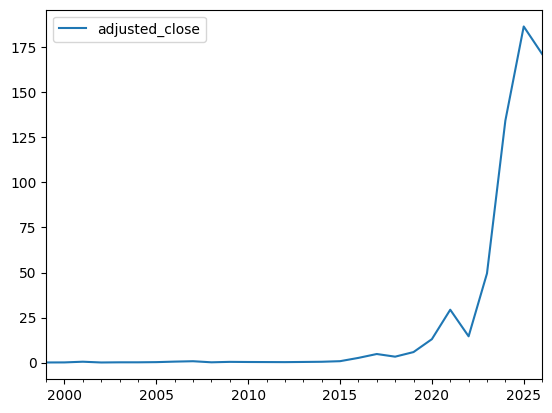

In [54]:
price_df.plot();

In [55]:
last_price = int(price_df['adjusted_close'].iloc[-1])
last_price

171

In [56]:
income_df = pd.read_csv(path + 'income_df.csv')
fcf_df = pd.read_csv(path + 'fcf_df.csv')
roic_df = pd.read_csv(path + 'roic_df.csv')
kpis_df = pd.read_csv(path + 'kpis_df.csv')

### More Engineering...

In [57]:
# Convert fiscalDateEnding to datetime for merging
income_df['fiscalDateEnding'] = pd.to_datetime(income_df['fiscalDateEnding'], errors='coerce')
fcf_df['fiscalDateEnding'] = pd.to_datetime(fcf_df['fiscalDateEnding'], errors='coerce')
roic_df['fiscalDateEnding'] = pd.to_datetime(roic_df['fiscalDateEnding'], errors='coerce')

In [58]:
financial_df = pd.merge(income_df, fcf_df, on='fiscalDateEnding', how='left')
financial_df = pd.merge(financial_df, roic_df, on='fiscalDateEnding', how='left')

In [59]:
financial_df.shape

(20, 54)

In [60]:
financial_df.head()

,fiscalDateEnding,totalRevenue,totalRevenue_YoY_growth%,ebitda_x,ebitdaMargin%,ebitda_YoY_growth%,depreciationDepletionAndAmortization,operatingIncome,ebitMargin%,operatingIncome_YoY_growth%,interestExpense_x,interestIncome,netInterest,incomeBeforeTax,incomeTaxExpense_x,taxRate%,netIncome,netIncomeMargin%,netIncome_YoY_growth%,reportedEPS,reportedEPS_YoY_growth%,commonStockSharesOutstanding,commonStockSharesOutstanding_YoY_growth%,ebitda_y,capitalExpenditures,maintenanceCapex,growthCapex,interestExpense_y,incomeTaxExpense_y,inventory,currentNetReceivables,currentAccountsPayable,deferredRevenue,workingCapital,changeInWC,freeCashFlow,freeCashFlow_YoY_growth%,freeCashFlowPerShare,freeCashFlowPerShare_YoY_growth%,maintenanceCapexMargin%,workingCapitalMargin%,freeCashFlowMargin%,cashConversion%,cashAndShortTermInvestments,shortTermInvestments,shortTermDebt,longTermDebt,capitalLeaseObligations,totalShareholderEquity,investedCapital,ROA%,ROE%,ROIC%,reinvestmentRate%
0,2026-01-31,215938000000,65.47,144552000000,66.94,67.82,2843000000,130387000000,60.38,60.08,259000000,2300000000.00,2041000000.00,141450000000,21383000000,15.12,120067000000,55.60,64.75,4.78,59.76,24432000000,-1.50,133230000000,6042000000,2843000000,3199000000,259000000,21383000000,21403000000,38466000000,9812000000,381000000,49676000000,22920000000.00,85825000000.00,53.75,3.51,56.09,1.32,23.00,39.75,64.42,10605000000,51951000000,1371000000.00,7469000000.00,2572000000.00,157293000000,116754000000.00,58.06,76.33,94.79,3.73
1,2025-01-31,130497000000,114.20,86137000000,66.01,142.07,1864000000,81453000000,62.42,147.04,247000000,1786000000.00,1539000000.00,84026000000,11146000000,13.26,72880000000,55.85,144.89,2.99,130.69,24804000000,-0.55,83317000000,3236000000,1864000000,1372000000,247000000,11146000000,10080000000,23065000000,6310000000,79000000,26756000000,14239000000.00,55821000000.00,148.55,2.25,149.91,1.43,20.50,42.78,67.00,8589000000,34621000000,288000000.00,8463000000.00,1807000000.00,79327000000,55264000000.00,65.30,91.87,127.84,2.46
2,2024-01-31,60922000000,125.85,35583000000,58.41,494.44,1508000000,32972000000,54.12,680.59,257000000,866000000.00,609000000.00,33818000000,4058000000,12.00,29760000000,48.85,581.32,1.30,289.49,24940000000,-0.52,34480000000,1069000000,1069000000,0,257000000,4058000000,5282000000,9999000000,2699000000,65000000,12517000000,6637000000.00,22459000000.00,926.46,0.90,931.81,1.75,20.55,36.87,65.14,7280000000,18704000000,1478000000.00,8459000000.00,1347000000.00,42978000000,35558000000.00,45.28,69.24,81.60,0.00
3,2023-01-31,26974000000,0.22,5986000000,22.19,-47.26,1544000000,4224000000,15.66,-57.93,262000000,267000000.00,5000000.00,4181000000,-187000000,-4.47,4368000000,16.19,-55.21,0.33,-25.08,25070000000,-1.10,5768000000,1833000000,1544000000,289000000,262000000,-187000000,5159000000,3827000000,1193000000,1913000000,5880000000,1961000000.00,2188000000.00,-68.47,0.09,-68.12,5.72,21.80,8.11,37.93,3389000000,9907000000,1250000000.00,9703000000.00,902000000.00,22101000000,24049000000.00,10.61,19.76,18.35,13.21
4,2022-01-31,26914000000,61.40,11351000000,42.18,99.46,1174000000,10041000000,37.31,121.56,236000000,29000000.00,-207000000.00,9941000000,189000000,1.90,9752000000,36.23,125.12,0.44,77.45,25350000000,0.92,11215000000,976000000,976000000,0,236000000,189000000,2605000000,4650000000,1783000000,1553000000,3919000000,2874000000.00,6940000000.00,80.78,0.27,79.14,3.63,14.56,25.79,61.88,1990000000,19218000000,144000000.00,10946000000.00,741000000.00,26612000000,19225000000.00,22.07,36.65,51.24,0.00


In [61]:
financial_df['netDebt'] = financial_df['shortTermDebt']+financial_df['longTermDebt']-financial_df['cashAndShortTermInvestments']-financial_df['shortTermInvestments']
financial_df['netDebt/EBITDA'] = financial_df['netDebt']/financial_df['ebitda_y']

In [62]:
financial_df.head()

,fiscalDateEnding,totalRevenue,totalRevenue_YoY_growth%,ebitda_x,ebitdaMargin%,ebitda_YoY_growth%,depreciationDepletionAndAmortization,operatingIncome,ebitMargin%,operatingIncome_YoY_growth%,interestExpense_x,interestIncome,netInterest,incomeBeforeTax,incomeTaxExpense_x,taxRate%,netIncome,netIncomeMargin%,netIncome_YoY_growth%,reportedEPS,reportedEPS_YoY_growth%,commonStockSharesOutstanding,commonStockSharesOutstanding_YoY_growth%,ebitda_y,capitalExpenditures,maintenanceCapex,growthCapex,interestExpense_y,incomeTaxExpense_y,inventory,currentNetReceivables,currentAccountsPayable,deferredRevenue,workingCapital,changeInWC,freeCashFlow,freeCashFlow_YoY_growth%,freeCashFlowPerShare,freeCashFlowPerShare_YoY_growth%,maintenanceCapexMargin%,workingCapitalMargin%,freeCashFlowMargin%,cashConversion%,cashAndShortTermInvestments,shortTermInvestments,shortTermDebt,longTermDebt,capitalLeaseObligations,totalShareholderEquity,investedCapital,ROA%,ROE%,ROIC%,reinvestmentRate%,netDebt,netDebt/EBITDA
0,2026-01-31,215938000000,65.47,144552000000,66.94,67.82,2843000000,130387000000,60.38,60.08,259000000,2300000000.00,2041000000.00,141450000000,21383000000,15.12,120067000000,55.60,64.75,4.78,59.76,24432000000,-1.50,133230000000,6042000000,2843000000,3199000000,259000000,21383000000,21403000000,38466000000,9812000000,381000000,49676000000,22920000000.00,85825000000.00,53.75,3.51,56.09,1.32,23.00,39.75,64.42,10605000000,51951000000,1371000000.00,7469000000.00,2572000000.00,157293000000,116754000000.00,58.06,76.33,94.79,3.73,-53716000000.00,-0.40
1,2025-01-31,130497000000,114.20,86137000000,66.01,142.07,1864000000,81453000000,62.42,147.04,247000000,1786000000.00,1539000000.00,84026000000,11146000000,13.26,72880000000,55.85,144.89,2.99,130.69,24804000000,-0.55,83317000000,3236000000,1864000000,1372000000,247000000,11146000000,10080000000,23065000000,6310000000,79000000,26756000000,14239000000.00,55821000000.00,148.55,2.25,149.91,1.43,20.50,42.78,67.00,8589000000,34621000000,288000000.00,8463000000.00,1807000000.00,79327000000,55264000000.00,65.30,91.87,127.84,2.46,-34459000000.00,-0.41
2,2024-01-31,60922000000,125.85,35583000000,58.41,494.44,1508000000,32972000000,54.12,680.59,257000000,866000000.00,609000000.00,33818000000,4058000000,12.00,29760000000,48.85,581.32,1.30,289.49,24940000000,-0.52,34480000000,1069000000,1069000000,0,257000000,4058000000,5282000000,9999000000,2699000000,65000000,12517000000,6637000000.00,22459000000.00,926.46,0.90,931.81,1.75,20.55,36.87,65.14,7280000000,18704000000,1478000000.00,8459000000.00,1347000000.00,42978000000,35558000000.00,45.28,69.24,81.60,0.00,-16047000000.00,-0.47
3,2023-01-31,26974000000,0.22,5986000000,22.19,-47.26,1544000000,4224000000,15.66,-57.93,262000000,267000000.00,5000000.00,4181000000,-187000000,-4.47,4368000000,16.19,-55.21,0.33,-25.08,25070000000,-1.10,5768000000,1833000000,1544000000,289000000,262000000,-187000000,5159000000,3827000000,1193000000,1913000000,5880000000,1961000000.00,2188000000.00,-68.47,0.09,-68.12,5.72,21.80,8.11,37.93,3389000000,9907000000,1250000000.00,9703000000.00,902000000.00,22101000000,24049000000.00,10.61,19.76,18.35,13.21,-2343000000.00,-0.41
4,2022-01-31,26914000000,61.40,11351000000,42.18,99.46,1174000000,10041000000,37.31,121.56,236000000,29000000.00,-207000000.00,9941000000,189000000,1.90,9752000000,36.23,125.12,0.44,77.45,25350000000,0.92,11215000000,976000000,976000000,0,236000000,189000000,2605000000,4650000000,1783000000,1553000000,3919000000,2874000000.00,6940000000.00,80.78,0.27,79.14,3.63,14.56,25.79,61.88,1990000000,19218000000,144000000.00,10946000000.00,741000000.00,26612000000,19225000000.00,22.07,36.65,51.24,0.00,-10118000000.00,-0.90


In [63]:
financial_df['marketCapitalization'] = financial_df['commonStockSharesOutstanding']*last_price
financial_df['enterpriseValue'] = financial_df['marketCapitalization'] + financial_df['netDebt']

In [64]:
financial_df.head()

,fiscalDateEnding,totalRevenue,totalRevenue_YoY_growth%,ebitda_x,ebitdaMargin%,ebitda_YoY_growth%,depreciationDepletionAndAmortization,operatingIncome,ebitMargin%,operatingIncome_YoY_growth%,interestExpense_x,interestIncome,netInterest,incomeBeforeTax,incomeTaxExpense_x,taxRate%,netIncome,netIncomeMargin%,netIncome_YoY_growth%,reportedEPS,reportedEPS_YoY_growth%,commonStockSharesOutstanding,commonStockSharesOutstanding_YoY_growth%,ebitda_y,capitalExpenditures,maintenanceCapex,growthCapex,interestExpense_y,incomeTaxExpense_y,inventory,currentNetReceivables,currentAccountsPayable,deferredRevenue,workingCapital,changeInWC,freeCashFlow,freeCashFlow_YoY_growth%,freeCashFlowPerShare,freeCashFlowPerShare_YoY_growth%,maintenanceCapexMargin%,workingCapitalMargin%,freeCashFlowMargin%,cashConversion%,cashAndShortTermInvestments,shortTermInvestments,shortTermDebt,longTermDebt,capitalLeaseObligations,totalShareholderEquity,investedCapital,ROA%,ROE%,ROIC%,reinvestmentRate%,netDebt,netDebt/EBITDA,marketCapitalization,enterpriseValue
0,2026-01-31,215938000000,65.47,144552000000,66.94,67.82,2843000000,130387000000,60.38,60.08,259000000,2300000000.00,2041000000.00,141450000000,21383000000,15.12,120067000000,55.60,64.75,4.78,59.76,24432000000,-1.50,133230000000,6042000000,2843000000,3199000000,259000000,21383000000,21403000000,38466000000,9812000000,381000000,49676000000,22920000000.00,85825000000.00,53.75,3.51,56.09,1.32,23.00,39.75,64.42,10605000000,51951000000,1371000000.00,7469000000.00,2572000000.00,157293000000,116754000000.00,58.06,76.33,94.79,3.73,-53716000000.00,-0.40,4177872000000,4124156000000.00
1,2025-01-31,130497000000,114.20,86137000000,66.01,142.07,1864000000,81453000000,62.42,147.04,247000000,1786000000.00,1539000000.00,84026000000,11146000000,13.26,72880000000,55.85,144.89,2.99,130.69,24804000000,-0.55,83317000000,3236000000,1864000000,1372000000,247000000,11146000000,10080000000,23065000000,6310000000,79000000,26756000000,14239000000.00,55821000000.00,148.55,2.25,149.91,1.43,20.50,42.78,67.00,8589000000,34621000000,288000000.00,8463000000.00,1807000000.00,79327000000,55264000000.00,65.30,91.87,127.84,2.46,-34459000000.00,-0.41,4241484000000,4207025000000.00
2,2024-01-31,60922000000,125.85,35583000000,58.41,494.44,1508000000,32972000000,54.12,680.59,257000000,866000000.00,609000000.00,33818000000,4058000000,12.00,29760000000,48.85,581.32,1.30,289.49,24940000000,-0.52,34480000000,1069000000,1069000000,0,257000000,4058000000,5282000000,9999000000,2699000000,65000000,12517000000,6637000000.00,22459000000.00,926.46,0.90,931.81,1.75,20.55,36.87,65.14,7280000000,18704000000,1478000000.00,8459000000.00,1347000000.00,42978000000,35558000000.00,45.28,69.24,81.60,0.00,-16047000000.00,-0.47,4264740000000,4248693000000.00
3,2023-01-31,26974000000,0.22,5986000000,22.19,-47.26,1544000000,4224000000,15.66,-57.93,262000000,267000000.00,5000000.00,4181000000,-187000000,-4.47,4368000000,16.19,-55.21,0.33,-25.08,25070000000,-1.10,5768000000,1833000000,1544000000,289000000,262000000,-187000000,5159000000,3827000000,1193000000,1913000000,5880000000,1961000000.00,2188000000.00,-68.47,0.09,-68.12,5.72,21.80,8.11,37.93,3389000000,9907000000,1250000000.00,9703000000.00,902000000.00,22101000000,24049000000.00,10.61,19.76,18.35,13.21,-2343000000.00,-0.41,4286970000000,4284627000000.00
4,2022-01-31,26914000000,61.40,11351000000,42.18,99.46,1174000000,10041000000,37.31,121.56,236000000,29000000.00,-207000000.00,9941000000,189000000,1.90,9752000000,36.23,125.12,0.44,77.45,25350000000,0.92,11215000000,976000000,976000000,0,236000000,189000000,2605000000,4650000000,1783000000,1553000000,3919000000,2874000000.00,6940000000.00,80.78,0.27,79.14,3.63,14.56,25.79,61.88,1990000000,19218000000,144000000.00,10946000000.00,741000000.00,26612000000,19225000000.00,22.07,36.65,51.24,0.00,-10118000000.00,-0.90,4334850000000,4324732000000.00


### Valuation Multiples

In [65]:
financial_df['PER'] = financial_df['marketCapitalization']/financial_df['netIncome']
financial_df['EV/FCF'] = financial_df['enterpriseValue']/financial_df['freeCashFlow']
financial_df['EV/EBITDA'] = financial_df['enterpriseValue']/financial_df['ebitda_y']
financial_df['EV/EBIT'] = financial_df['enterpriseValue']/financial_df['operatingIncome']

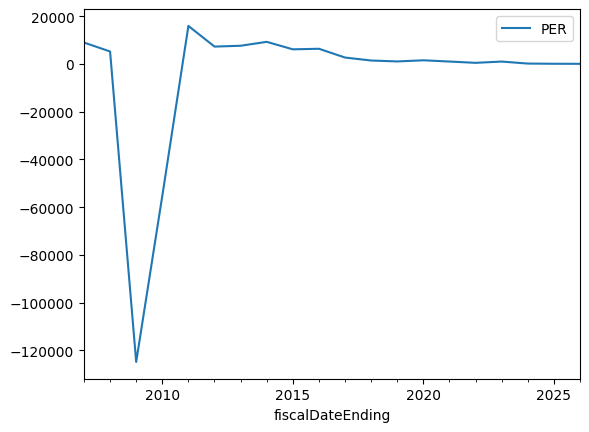

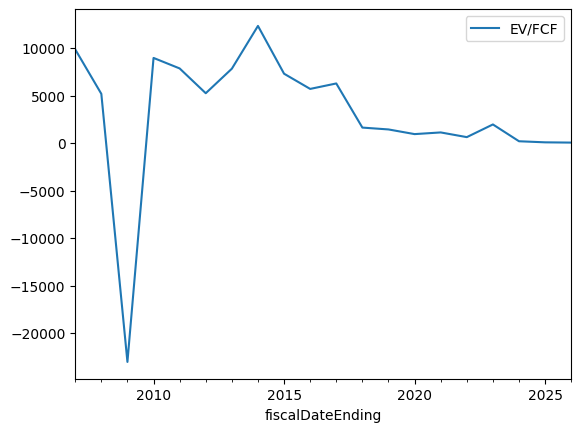

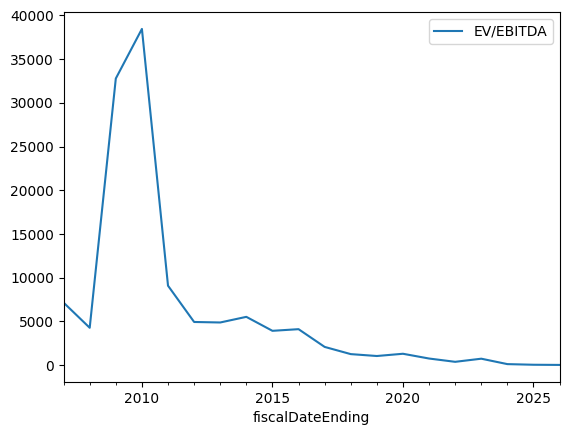

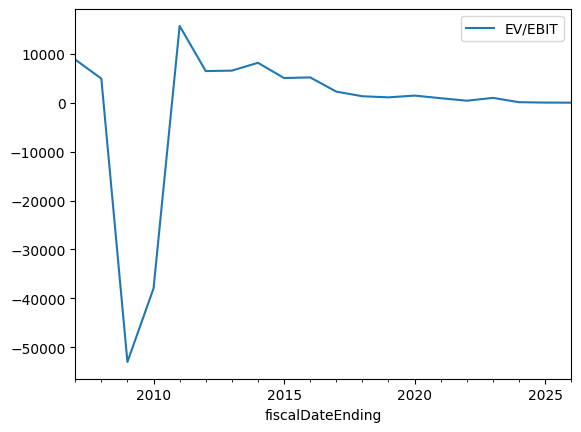

In [66]:
for multiple in ['PER','EV/FCF','EV/EBITDA','EV/EBIT']:
    financial_df[['fiscalDateEnding',multiple]].plot(x='fiscalDateEnding', y=multiple);

In [67]:
financial_df[['PER','EV/FCF','EV/EBITDA','EV/EBIT']].loc[0]

,0
PER,34.80
EV/FCF,48.05
EV/EBITDA,30.96
EV/EBIT,31.63


In [68]:
per_multiple = int(financial_df['PER'].iloc[0])
ev_fcf_multiple = int(financial_df['EV/FCF'].iloc[0])
ev_ebitda_multiple = int(financial_df['EV/EBITDA'].iloc[0])
ev_ebit_multiple = int(financial_df['EV/EBIT'].iloc[0])

In [69]:
per_multiple, ev_fcf_multiple, ev_ebitda_multiple, ev_ebit_multiple

(34, 48, 30, 31)

### Modeling

In [70]:
forecast_df = financial_df[['fiscalDateEnding','commonStockSharesOutstanding','netDebt','freeCashFlow','operatingIncome','netIncome','ebitda_y']].copy()

In [71]:
forecast_df['fiscalDateEnding'] = pd.to_datetime(forecast_df['fiscalDateEnding'], errors='coerce')
forecast_df = forecast_df.sort_values(by='fiscalDateEnding').reset_index(drop=True)

In [72]:
numerical_cols = ['commonStockSharesOutstanding','netDebt','freeCashFlow','operatingIncome','netIncome','ebitda_y']
last_historical_values = forecast_df[numerical_cols].iloc[-1]

In [73]:
last_year = forecast_df['fiscalDateEnding'].dt.year.max()
future_years = pd.to_datetime([f"{last_year + i}-12-31" for i in range(1, 6)])

In [74]:
future_years

DatetimeIndex(['2027-12-31', '2028-12-31', '2029-12-31', '2030-12-31',
               '2031-12-31'],
              dtype='datetime64[ns]', freq=None)

In [75]:
future_df = pd.DataFrame({'fiscalDateEnding': future_years})

for col in numerical_cols:
    future_df[col] = last_historical_values[col]

extended_forecast_df = pd.concat([forecast_df, future_df], ignore_index=True)
extended_forecast_df = extended_forecast_df.sort_values(by='fiscalDateEnding').reset_index(drop=True)

In [76]:
extended_forecast_df.tail()

,fiscalDateEnding,commonStockSharesOutstanding,netDebt,freeCashFlow,operatingIncome,netIncome,ebitda_y
20,2027-12-31,24432000000.00,-53716000000.00,85825000000.00,130387000000.00,120067000000.00,133230000000.00
21,2028-12-31,24432000000.00,-53716000000.00,85825000000.00,130387000000.00,120067000000.00,133230000000.00
22,2029-12-31,24432000000.00,-53716000000.00,85825000000.00,130387000000.00,120067000000.00,133230000000.00
23,2030-12-31,24432000000.00,-53716000000.00,85825000000.00,130387000000.00,120067000000.00,133230000000.00
24,2031-12-31,24432000000.00,-53716000000.00,85825000000.00,130387000000.00,120067000000.00,133230000000.00


In [77]:
numerical_cols_extended = extended_forecast_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
valuation_df = pd.DataFrame({'fiscalDateEnding': extended_forecast_df['fiscalDateEnding']})

for col in numerical_cols_extended:
    valuation_df[f'EMA_5Y_{col}'] = extended_forecast_df[col].ewm(span=5, adjust=False).mean()

In [78]:
valuation_df.tail()

,fiscalDateEnding,EMA_5Y_commonStockSharesOutstanding,EMA_5Y_netDebt,EMA_5Y_freeCashFlow,EMA_5Y_operatingIncome,EMA_5Y_netIncome,EMA_5Y_ebitda_y
20,2027-12-31,24655111603.94,-37608723954.46,58889204530.37,88763597131.72,81433267898.02,90969505929.11
21,2028-12-31,24580741069.29,-42977815969.64,67867803020.25,102638064754.48,94311178598.68,105056337286.07
22,2029-12-31,24531160712.86,-46557210646.43,73853535346.83,111887709836.32,102896452399.12,114447558190.71
23,2030-12-31,24498107141.91,-48943473764.28,77844023564.55,118054139890.88,108619968266.08,120708372127.14
24,2031-12-31,24476071427.94,-50534315842.86,80504349043.04,122165093260.59,112435645510.72,124882248084.76


### Valuation

In [79]:
per_multiple, ev_fcf_multiple, ev_ebitda_multiple, ev_ebit_multiple

(34, 48, 30, 31)

In [80]:
valuation_df['priceEV/FCF'] = ((valuation_df['EMA_5Y_freeCashFlow'] * ev_fcf_multiple) - valuation_df['EMA_5Y_netDebt']) / valuation_df['EMA_5Y_commonStockSharesOutstanding']
valuation_df['priceEV/EBITDA'] = ((valuation_df['EMA_5Y_ebitda_y'] * ev_ebitda_multiple) - valuation_df['EMA_5Y_netDebt']) / valuation_df['EMA_5Y_commonStockSharesOutstanding']
valuation_df['priceEV/EBIT'] = ((valuation_df['EMA_5Y_operatingIncome'] * ev_ebit_multiple) - valuation_df['EMA_5Y_netDebt']) / valuation_df['EMA_5Y_commonStockSharesOutstanding']

In [81]:
valuation_df['pricePERexCash'] = np.where(
    valuation_df['EMA_5Y_netDebt'] < 0,
    ((valuation_df['EMA_5Y_netIncome'] * per_multiple) - valuation_df['EMA_5Y_netDebt']) / valuation_df['EMA_5Y_commonStockSharesOutstanding'],
    (valuation_df['EMA_5Y_netIncome'] * per_multiple) / valuation_df['EMA_5Y_commonStockSharesOutstanding']
)

In [82]:
valuation_df.tail()

,fiscalDateEnding,EMA_5Y_commonStockSharesOutstanding,EMA_5Y_netDebt,EMA_5Y_freeCashFlow,EMA_5Y_operatingIncome,EMA_5Y_netIncome,EMA_5Y_ebitda_y,priceEV/FCF,priceEV/EBITDA,priceEV/EBIT,pricePERexCash
20,2027-12-31,24655111603.94,-37608723954.46,58889204530.37,88763597131.72,81433267898.02,90969505929.11,116.17,112.22,113.13,113.82
21,2028-12-31,24580741069.29,-42977815969.64,67867803020.25,102638064754.48,94311178598.68,105056337286.07,134.28,129.97,131.19,132.20
22,2029-12-31,24531160712.86,-46557210646.43,73853535346.83,111887709836.32,102896452399.12,114447558190.71,146.41,141.86,143.29,144.51
23,2030-12-31,24498107141.91,-48943473764.28,77844023564.55,118054139890.88,108619968266.08,120708372127.14,154.52,149.82,151.38,152.75
24,2031-12-31,24476071427.94,-50534315842.86,80504349043.04,122165093260.59,112435645510.72,124882248084.76,159.94,155.13,156.79,158.25


In [83]:
intrinsic_value = valuation_df[['fiscalDateEnding','priceEV/FCF','priceEV/EBITDA','priceEV/EBIT','pricePERexCash']].tail()

In [84]:
intrinsic_value.set_index('fiscalDateEnding', inplace=True)

In [85]:
intrinsic_value

,priceEV/FCF,priceEV/EBITDA,priceEV/EBIT,pricePERexCash
fiscalDateEnding,,,,
2027-12-31,116.17,112.22,113.13,113.82
2028-12-31,134.28,129.97,131.19,132.20
2029-12-31,146.41,141.86,143.29,144.51
2030-12-31,154.52,149.82,151.38,152.75
2031-12-31,159.94,155.13,156.79,158.25


In [86]:
intrinsic_value.iloc[-1].median()

157.52116292090867

In [87]:
last_price

171

In [88]:
profitability = np.round((intrinsic_value.iloc[-1].median()*100/last_price)**(1/5)-1, 2)
profitability

np.float64(1.47)

CAGR: 13% vs 7%